In [41]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "output" / "training_data_v6_no0min_trial.csv"
INSPECTION_PLAYERS_PATH = BASE_DIR / "data" / "Players for inspection.csv"

OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(exist_ok=True)

OUT_PATH = OUT_DIR / "inspection_data_2025_26.csv"

print("Loading datasets...")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
players_inspect = pd.read_csv(INSPECTION_PLAYERS_PATH, encoding="utf-8-sig")

print(f"Full dataset rows: {len(df):,}")
print(f"Inspection players: {players_inspect['Player UUID'].nunique():,}")

df_2526 = df[df["season"] == "2025-26"].copy()
print(f"Rows after season filter (2025-26): {len(df_2526):,}")

df_2526_inspection = df_2526.merge(
    players_inspect[["Player UUID"]],
    on="Player UUID",
    how="inner"
)

print(f"Rows after inspection-player filter: {len(df_2526_inspection):,}")
print(f"Unique players kept: {df_2526_inspection['Player UUID'].nunique():,}")

df_2526_inspection = df_2526_inspection.sort_values(
    ["Player UUID", "Gameweek"]
).reset_index(drop=True)

df_2526_inspection.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

print(f"Saved inspection dataset to: {OUT_PATH}")


Loading datasets...
Full dataset rows: 25,735
Inspection players: 12
Rows after season filter (2025-26): 3,370
Rows after inspection-player filter: 126
Unique players kept: 12
Saved inspection dataset to: ..\output\inspection_data_2025_26.csv


In [ ]:
def update_model_performance(model_name, mae_train, mae_val, rmse_train, rmse_val):
    perf_path = Path("../output/models/models_performance.csv")
    
    new_row = pd.DataFrame([{
        "Model": model_name,
        "MAE_Train": round(mae_train, 4),
        "MAE_Validation": round(mae_val, 4),
        "RMSE_Train": round(rmse_train, 4),
        "RMSE_Validation": round(rmse_val, 4),
        "Improvement_vs_Baseline (%)": 0.0
    }])

    if perf_path.exists():
        perf_df = pd.read_csv(perf_path)
        
        
        
        perf_df = perf_df[perf_df["Model"] != model_name].copy()
        
        #Improvement = {MAE_{Baseline} - MAE_{Model}}/{MAE_{Baseline} x 100%
        baseline_row = perf_df[perf_df["Model"].str.contains("Rolling Average", na=False)]
        
        if not baseline_row.empty and "Rolling Average" not in model_name:
            baseline_mae = baseline_row.iloc[0]["MAE_Validation"]
            improvement = ((baseline_mae - mae_val) / baseline_mae) * 100
            new_row.loc[0, "Improvement_vs_Baseline (%)"] = round(improvement, 2)
            
        # Προσθήκη της ενημερωμένης γραμμής
        perf_df = pd.concat([perf_df, new_row], ignore_index=True)
    else:
        perf_df = new_row
        perf_path.parent.mkdir(parents=True, exist_ok=True)

    
    perf_df.to_csv(perf_path, index=False, encoding="utf-8-sig")
    print(f" model_performance.csv updated (Overwrite): {model_name}")
    return perf_df

In [43]:

DATA_PATH = Path("..") / "output" / "inspection_data_2025_26.csv"

print("Loading inspection dataset...")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"Rows: {len(df):,}")
print(f"Players: {df['Player UUID'].nunique():,}")
print(f"Gameweeks range: {df['Gameweek'].min()} to {df['Gameweek'].max()}")

df = df.sort_values(["Player UUID", "Gameweek"]).reset_index(drop=True)

df.head()


Loading inspection dataset...
Rows: 126
Players: 12
Gameweeks range: 1 to 11


,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Team_Total_Points_GW,Team_Total_Points,Player_Season_Points,Team_Points_Contribution_GW,Team_Points_Contribution_Causal,Team_Points_Contribution_GW_Pct,Team_Points_Contribution_Causal_Pct,Team_Contribution_Rank_GW,Team_Contribution_Rank_Causal,element_type
0,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,1,90,0,0,...,18,0.0,0.0,0.111111,0.000000,11.11,0.00,0.032258,0.032258,2
1,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,2,90,0,0,...,24,18.0,2.0,0.083333,0.111111,8.33,11.11,0.096774,0.032258,2
2,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,3,90,1,0,...,80,42.0,4.0,0.112500,0.095238,11.25,9.52,0.093750,0.062500,2
3,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,4,90,0,0,...,19,122.0,13.0,0.105263,0.106557,10.53,10.66,0.058824,0.088235,2
4,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,5,90,1,0,...,30,141.0,15.0,0.300000,0.106383,30.00,10.64,0.029412,0.058824,2


In [44]:


print("Creating Target_NextGW...")

df["Target_NextGW"] = (
    df.groupby("Player UUID")["Total Points"]
      .shift(-1)
)

rows_before = len(df)

df = df.dropna(subset=["Target_NextGW"]).reset_index(drop=True)

rows_after = len(df)

df["Target_NextGW"] = df["Target_NextGW"].astype(float)

print(f"Rows before target drop: {rows_before}")
print(f"Rows after target drop:  {rows_after}")
print(f"Removed rows (last GW per player): {rows_before - rows_after}")

print("Remaining GW range:",
      df["Gameweek"].min(),
      "to",
      df["Gameweek"].max())

df.head()


Creating Target_NextGW...
Rows before target drop: 126
Rows after target drop:  114
Removed rows (last GW per player): 12
Remaining GW range: 1 to 10


,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Team_Total_Points,Player_Season_Points,Team_Points_Contribution_GW,Team_Points_Contribution_Causal,Team_Points_Contribution_GW_Pct,Team_Points_Contribution_Causal_Pct,Team_Contribution_Rank_GW,Team_Contribution_Rank_Causal,element_type,Target_NextGW
0,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,1,90,0,0,...,0.0,0.0,0.111111,0.000000,11.11,0.00,0.032258,0.032258,2,2.0
1,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,2,90,0,0,...,18.0,2.0,0.083333,0.111111,8.33,11.11,0.096774,0.032258,2,9.0
2,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,3,90,1,0,...,42.0,4.0,0.112500,0.095238,11.25,9.52,0.093750,0.062500,2,2.0
3,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,4,90,0,0,...,122.0,13.0,0.105263,0.106557,10.53,10.66,0.058824,0.088235,2,9.0
4,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,5,90,1,0,...,141.0,15.0,0.300000,0.106383,30.00,10.64,0.029412,0.058824,2,9.0


In [45]:
print("Creating time-based train / validation split...")

df["Split"] = "Train"

df.loc[df["Gameweek"] == 10, "Split"] = "Validation"

print(df["Split"].value_counts())

print("\nValidation rows (should be only GW10):")
print(df[df["Split"] == "Validation"][["Player UUID", "Gameweek"]].head())

df.head()


Creating time-based train / validation split...
Split
Train         103
Validation     11
Name: count, dtype: int64

Validation rows (should be only GW10):
                             Player UUID  Gameweek
9   1c2cd056-ee23-405d-bb00-490a255141a1        10
17  25926206-fae1-4680-a16f-a85d1bc6a5ea        10
27  3b8f2901-f6f2-483f-bd20-8ddb408e5c63        10
37  40226e47-afdf-40c8-8d2f-d8d044a0e545        10
47  47cecb8e-adce-4abe-bdbe-ccc1bfd57a0f        10


,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Player_Season_Points,Team_Points_Contribution_GW,Team_Points_Contribution_Causal,Team_Points_Contribution_GW_Pct,Team_Points_Contribution_Causal_Pct,Team_Contribution_Rank_GW,Team_Contribution_Rank_Causal,element_type,Target_NextGW,Split
0,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,1,90,0,0,...,0.0,0.111111,0.000000,11.11,0.00,0.032258,0.032258,2,2.0,Train
1,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,2,90,0,0,...,2.0,0.083333,0.111111,8.33,11.11,0.096774,0.032258,2,9.0,Train
2,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,3,90,1,0,...,4.0,0.112500,0.095238,11.25,9.52,0.093750,0.062500,2,2.0,Train
3,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,4,90,0,0,...,13.0,0.105263,0.106557,10.53,10.66,0.058824,0.088235,2,9.0,Train
4,1c2cd056-ee23-405d-bb00-490a255141a1,624,Jarrod Bowen,Bowen,West Ham,2025-26,5,90,1,0,...,15.0,0.300000,0.106383,30.00,10.64,0.029412,0.058824,2,9.0,Train


In [46]:
print("Computing rolling average baseline (window = 3)...")

ROLLING_WINDOW = 3

df["Rolling_Pred"] = (
    df.groupby("Player UUID")["Total Points"]
      .transform(lambda s: s.rolling(ROLLING_WINDOW, min_periods=1).mean())
)

df["Prediction_GW"] = df["Gameweek"] + 1

print(df[[
    "Player UUID",
    "Gameweek",
    "Prediction_GW",
    "Total Points",
    "Rolling_Pred",
    "Target_NextGW"
]].head(10))


Computing rolling average baseline (window = 3)...
                            Player UUID  Gameweek  Prediction_GW  \
0  1c2cd056-ee23-405d-bb00-490a255141a1         1              2   
1  1c2cd056-ee23-405d-bb00-490a255141a1         2              3   
2  1c2cd056-ee23-405d-bb00-490a255141a1         3              4   
3  1c2cd056-ee23-405d-bb00-490a255141a1         4              5   
4  1c2cd056-ee23-405d-bb00-490a255141a1         5              6   
5  1c2cd056-ee23-405d-bb00-490a255141a1         6              7   
6  1c2cd056-ee23-405d-bb00-490a255141a1         7              8   
7  1c2cd056-ee23-405d-bb00-490a255141a1         8              9   
8  1c2cd056-ee23-405d-bb00-490a255141a1         9             10   
9  1c2cd056-ee23-405d-bb00-490a255141a1        10             11   

   Total Points  Rolling_Pred  Target_NextGW  
0             2      2.000000            2.0  
1             2      2.000000            9.0  
2             9      4.333333            2.0  
3           

In [ ]:
import numpy as np

print("Defining Train / Validation split based on Prediction_GW...")

df["Split"] = "Train"
df.loc[df["Prediction_GW"].isin([10, 11]), "Split"] = "Validation"

print(df["Split"].value_counts())

print("\nValidation check (Prediction_GW should be 10 or 11):")
print(
    df[df["Split"] == "Validation"][
        ["Player UUID", "Gameweek", "Prediction_GW"]
    ].head(10)
)

print("\nComputing errors for rolling baseline...")

df["Error_Rolling"] = (
    df["Target_NextGW"] - df["Rolling_Pred"]
).abs()

mae_train = df[df["Split"] == "Train"]["Error_Rolling"].mean()
mae_val   = df[df["Split"] == "Validation"]["Error_Rolling"].mean()

rmse_train = np.sqrt(
    np.mean(
        (df[df["Split"] == "Train"]["Target_NextGW"]
         - df[df["Split"] == "Train"]["Rolling_Pred"]) ** 2
    )
)

rmse_val = np.sqrt(
    np.mean(
        (df[df["Split"] == "Validation"]["Target_NextGW"]
         - df[df["Split"] == "Validation"]["Rolling_Pred"]) ** 2
    )
)

print("\nRolling Average Baseline Performance:")
print(f"MAE Train: {mae_train:.4f}")
print(f"MAE Validation: {mae_val:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Validation: {rmse_val:.4f}")


update_model_performance(
    model_name="Rolling Average (window=3)", 
    mae_train=mae_train, 
    mae_val=mae_val, 
    rmse_train=rmse_train, 
    rmse_val=rmse_val
)

Defining Train / Validation split based on Prediction_GW...
Split
Train         92
Validation    22
Name: count, dtype: int64

Validation check (Prediction_GW should be 10 or 11):
                             Player UUID  Gameweek  Prediction_GW
8   1c2cd056-ee23-405d-bb00-490a255141a1         9             10
9   1c2cd056-ee23-405d-bb00-490a255141a1        10             11
16  25926206-fae1-4680-a16f-a85d1bc6a5ea         9             10
17  25926206-fae1-4680-a16f-a85d1bc6a5ea        10             11
26  3b8f2901-f6f2-483f-bd20-8ddb408e5c63         9             10
27  3b8f2901-f6f2-483f-bd20-8ddb408e5c63        10             11
36  40226e47-afdf-40c8-8d2f-d8d044a0e545         9             10
37  40226e47-afdf-40c8-8d2f-d8d044a0e545        10             11
46  47cecb8e-adce-4abe-bdbe-ccc1bfd57a0f         9             10
47  47cecb8e-adce-4abe-bdbe-ccc1bfd57a0f        10             11

Computing errors for rolling baseline...

Rolling Average Baseline Performance:
MAE Train: 3.

,Model,MAE_Train,MAE_Validation,RMSE_Train,RMSE_Validation,Improvement_vs_Baseline (%)
0,Rolling Average (window=3),3.6612,3.5758,5.1058,4.3228,0.0


In [48]:
from pathlib import Path

OUT_DIR = Path("..") / "output" / "models" / "baseline2" 
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving rolling baseline outputs...")

df_out = df.copy()

df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
df_out["Total_Points_Predicted"] = df_out["Rolling_Pred"]
df_out["Error(Actual−Predicted)"] = df_out["Error_Rolling"]

keep_cols = [
    "Player UUID",
    "Player Name",
    "Web Name",
    "Prediction_GW",
    "Total_Points_Actual",
    "Total_Points_Predicted",
    "Error(Actual−Predicted)",
    "Split"
]

df_out = df_out[keep_cols]

df_out.to_csv(
    OUT_DIR / "rolling_baseline_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

metrics = pd.DataFrame({
    "Model": ["Rolling Average (window=3)"],
    "MAE_Train": [round(mae_train, 4)],
    "MAE_Validation": [round(mae_val, 4)],
    "RMSE_Train": [round(rmse_train, 4)],
    "RMSE_Validation": [round(rmse_val, 4)]
})

metrics.to_csv(
    OUT_DIR / "rolling_baseline_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rolling baseline saved successfully.")


Saving rolling baseline outputs...
Rolling baseline saved successfully.


**Linear Regression**

In [49]:
import pandas as pd
import numpy as np

print("Preparing features for Linear Regression...")

df_lr = df.copy()

# 1. Is Home: True/False -> 0/1
df_lr["Is Home"] = df_lr["Is Home"].replace({True: 1, False: 0}).astype(int)


# 2. Select rolling average features L5
rolling_cols = [
    c for c in df_lr.columns
    if c.startswith("Avg_") and ("_L5" in c)
]

print(f"Rolling features selected: {len(rolling_cols)}")


# 3. Context features (pre-match, non-leakage)
context_cols = [
    "Is Home",
    "Opponent Difficulty",
    "Position"
]


# 4. Build feature dataframe
X = df_lr[rolling_cols + context_cols].copy()

# One-hot encoding for Position
X = pd.get_dummies(X, columns=["Position"], drop_first=True)

# Target
y = df_lr["Target_NextGW"].astype(float)

print("Final feature matrix shape:", X.shape)
X.head()


Preparing features for Linear Regression...
Rolling features selected: 9
Final feature matrix shape: (114, 13)


C:\Users\SOFI\AppData\Local\Temp\ipykernel_12052\3472761225.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_lr["Is Home"] = df_lr["Is Home"].replace({True: 1, False: 0}).astype(int)


,Avg_Total Points_L5,Avg_Minutes Played_L5,Avg_Goals Scored_L5,Avg_Assists_L5,Avg_Goals Conceded_L5,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5,Is Home,Opponent Difficulty,Position_GK,Position_MID
0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000,0.000000,0,3,False,False
1,2.000000,90.0,0.000000,0.0,3.000000,4.900000,34.000000,4.300,10.600000,1,3,False,False
2,2.000000,90.0,0.000000,0.0,4.000000,5.500000,32.000000,12.750,10.200000,0,3,False,False
3,4.333333,90.0,0.333333,0.0,2.666667,6.766667,24.333333,19.700,23.533333,1,3,False,False
4,3.750000,90.0,0.250000,0.0,2.750000,6.475000,28.000000,15.875,20.750000,1,3,False,False


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import numpy as np

OUT_DIR = Path("..") / "output" / "models" / "linreg2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Training Linear Regression model...")

# Train / Validation split 
train_mask = df_lr["Split"] == "Train"
val_mask   = df_lr["Split"] == "Validation"

X_train = X.loc[train_mask]
X_val   = X.loc[val_mask]

y_train = y.loc[train_mask]
y_val   = y.loc[val_mask]


# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)


# Metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val   = mean_absolute_error(y_val, y_val_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val   = np.sqrt(mean_squared_error(y_val, y_val_pred))

print("Linear Regression performance:")
print(f"MAE Train: {mae_train:.4f}")
print(f"MAE Validation: {mae_val:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Validation: {rmse_val:.4f}")

# Ενημέρωση models_performance.csv για τη Linear Regression
update_model_performance(
    model_name="Linear Regression", 
    mae_train=mae_train, 
    mae_val=mae_val, 
    rmse_train=rmse_train, 
    rmse_val=rmse_val
)

# Save predictions 
df_out = df_lr.copy()

df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
df_out["Total_Points_Predicted"] = model.predict(X)
df_out["Error(Actual−Predicted)"] = (
    df_out["Total_Points_Actual"] - df_out["Total_Points_Predicted"]
).abs()

keep_cols = [
    "Player UUID",
    "Player Name",
    "Web Name",
    "Prediction_GW",
    "Total_Points_Actual",
    "Total_Points_Predicted",
    "Error(Actual−Predicted)",
    "Split"
]

df_out = df_out[keep_cols]

df_out.to_csv(
    OUT_DIR / "linear_regression_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)


# Save coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

intercept_row = pd.DataFrame([{
    "Feature": "Intercept",
    "Coefficient": model.intercept_
}])

coeff_df = pd.concat([intercept_row, coeff_df], ignore_index=True)

coeff_df.to_csv(
    OUT_DIR / "coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Linear regression outputs saved successfully.")


Training Linear Regression model...
Linear Regression performance:
MAE Train: 2.9113
MAE Validation: 3.2333
RMSE Train: 3.8934
RMSE Validation: 4.0238
✔️ Το αρχείο ενημερώθηκε (Overwrite): Linear Regression
Linear regression outputs saved successfully.


In [51]:
print("Features used in Linear Regression:\n")
for f in X_train.columns:
    print(f)

print("\nSummary statistics of TRAIN features:\n")
display(X_train.describe().T)


Features used in Linear Regression:

Avg_Total Points_L5
Avg_Minutes Played_L5
Avg_Goals Scored_L5
Avg_Assists_L5
Avg_Goals Conceded_L5
Avg_ICT Index_L5
Avg_Threat_L5
Avg_Creativity_L5
Avg_Influence_L5
Is Home
Opponent Difficulty
Position_GK
Position_MID

Summary statistics of TRAIN features:



,count,mean,std,min,25%,50%,75%,max
Avg_Total Points_L5,92.0,4.158877,2.944580,0.0,2.150000,3.775,6.000000,13.0
Avg_Minutes Played_L5,92.0,69.647645,32.718149,0.0,63.458333,90.000,90.000000,90.0
Avg_Goals Scored_L5,92.0,0.285507,0.391658,0.0,0.000000,0.200,0.400000,2.0
Avg_Assists_L5,92.0,0.056159,0.127403,0.0,0.000000,0.000,0.000000,0.5
Avg_Goals Conceded_L5,92.0,0.933514,0.894429,0.0,0.150000,0.900,1.500000,4.0
Avg_ICT Index_L5,92.0,4.604656,3.195778,0.0,2.750000,4.200,6.496250,13.4
Avg_Threat_L5,92.0,16.635688,17.102047,0.0,2.750000,11.100,25.850000,71.0
Avg_Creativity_L5,92.0,8.226649,7.878743,0.0,0.975000,5.845,13.648333,33.8
Avg_Influence_L5,92.0,21.146159,13.768465,0.0,11.587500,20.560,28.970000,58.0
Is Home,92.0,0.510870,0.502621,0.0,0.000000,1.000,1.000000,1.0


In [52]:
print("\nTarget (y_train) summary:\n")
display(y_train.describe())



Target (y_train) summary:



count    92.000000
mean      5.163043
std       4.222590
min       1.000000
25%       2.000000
50%       3.500000
75%       7.250000
max      24.000000
Name: Target_NextGW, dtype: float64

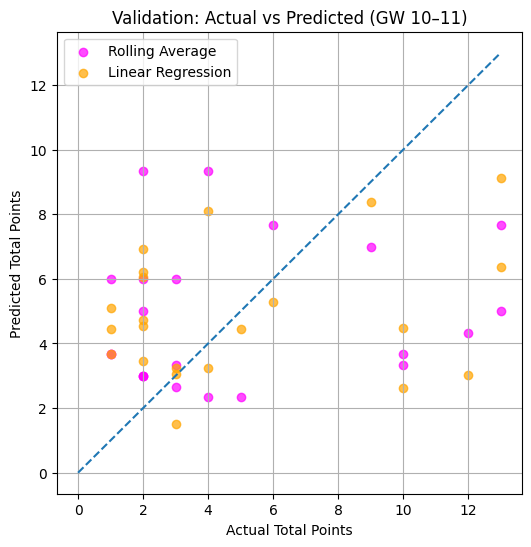

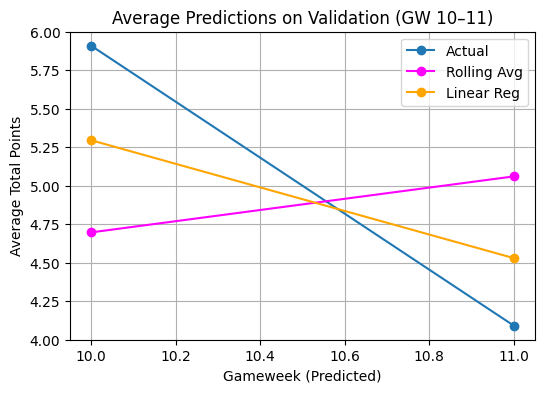

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..") / "output"

ROLLING_PATH = BASE_DIR / "models" / "baseline2" / "rolling_baseline_predictions.csv"
LINEAR_PATH  = BASE_DIR / "models" / "linreg2" / "linear_regression_predictions.csv"

df_roll = pd.read_csv(ROLLING_PATH, encoding="utf-8-sig")
df_lin  = pd.read_csv(LINEAR_PATH, encoding="utf-8-sig")

# Keep validation only
df_roll = df_roll[df_roll["Split"] == "Validation"]
df_lin  = df_lin[df_lin["Split"] == "Validation"]

# Merge
df_plot = df_roll.merge(
    df_lin,
    on=["Player UUID", "Prediction_GW"],
    suffixes=("_Rolling", "_Linear")
)

# PLOT 1 — Actual vs Predicted (Scatter)

plt.figure(figsize=(6, 6))

plt.scatter(
    df_plot["Total_Points_Actual_Rolling"],
    df_plot["Total_Points_Predicted_Rolling"],
    label="Rolling Average",
    color="magenta",
    alpha=0.7
)

plt.scatter(
    df_plot["Total_Points_Actual_Rolling"],
    df_plot["Total_Points_Predicted_Linear"],
    label="Linear Regression",
    color="orange",
    alpha=0.7
)

max_val = max(
    df_plot["Total_Points_Actual_Rolling"].max(),
    df_plot["Total_Points_Predicted_Linear"].max(),
    df_plot["Total_Points_Predicted_Rolling"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("Actual Total Points")
plt.ylabel("Predicted Total Points")
plt.title("Validation: Actual vs Predicted (GW 10–11)")
plt.legend()
plt.grid(True)
plt.show()


# PLOT 2 — Average Prediction per GW
avg_df = (
    df_plot
    .groupby("Prediction_GW")
    .agg(
        Actual=("Total_Points_Actual_Rolling", "mean"),
        Rolling=("Total_Points_Predicted_Rolling", "mean"),
        Linear=("Total_Points_Predicted_Linear", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(6, 4))

plt.plot(avg_df["Prediction_GW"], avg_df["Actual"], marker="o", label="Actual")
plt.plot(avg_df["Prediction_GW"], avg_df["Rolling"], marker="o", label="Rolling Avg", color="magenta")
plt.plot(avg_df["Prediction_GW"], avg_df["Linear"], marker="o", label="Linear Reg", color="orange")

plt.xlabel("Gameweek (Predicted)")
plt.ylabel("Average Total Points")
plt.title("Average Predictions on Validation (GW 10–11)")
plt.legend()
plt.grid(True)
plt.show()


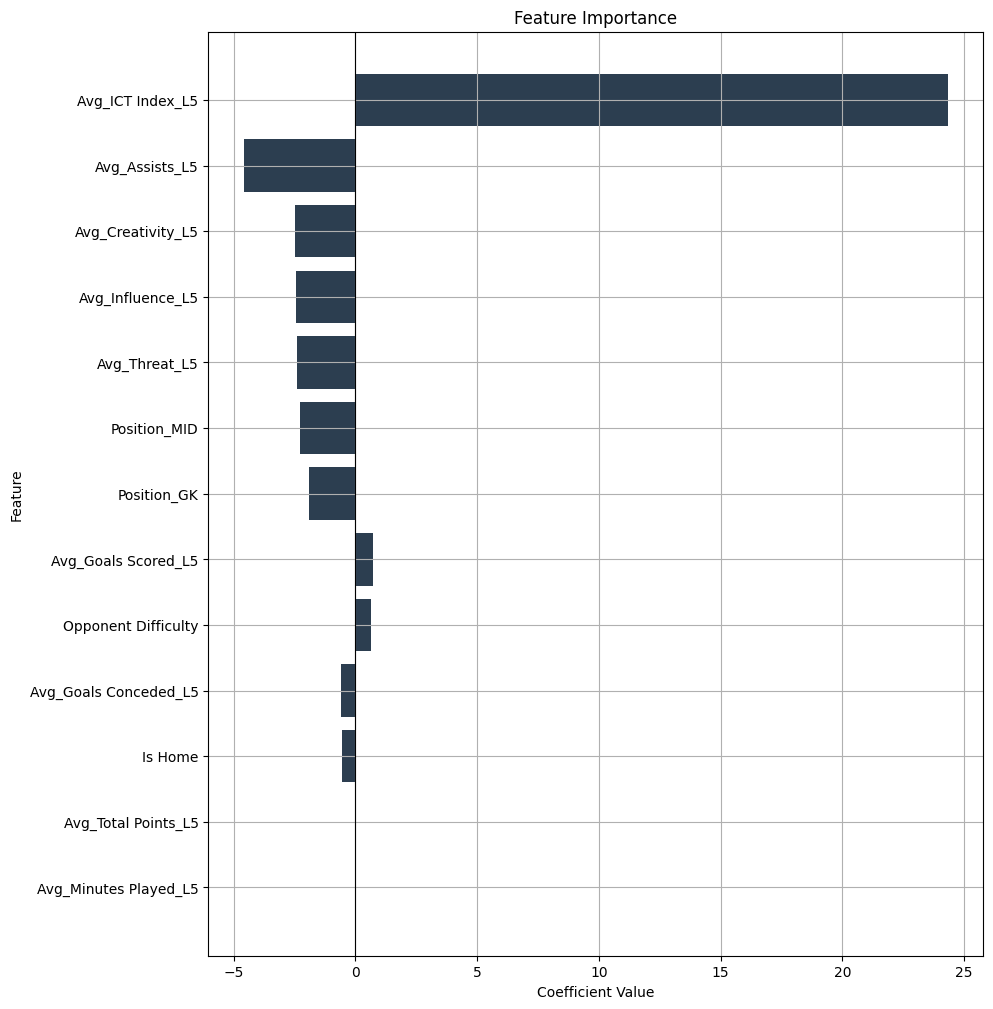

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

COEFF_PATH = Path("..") / "output" / "models" / "linreg2" / "coefficients.csv"

coeff_df = pd.read_csv(COEFF_PATH, encoding="utf-8-sig")

# Αφαιρούμε intercept
coeff_df = coeff_df[coeff_df["Feature"] != "Intercept"]

# Υπολογισμός απόλυτης τιμής για σωστή ταξινόμηση
coeff_df["AbsCoefficient"] = coeff_df["Coefficient"].abs()

# Ταξινόμηση (μικρά → μεγάλα για καθαρό plot)
coeff_df = coeff_df.sort_values("AbsCoefficient", ascending=True)

plt.figure(figsize=(10, 12))

plt.barh(
    coeff_df["Feature"],
    coeff_df["Coefficient"],
    color='#2C3E50'
)

plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.grid(True)
plt.show()


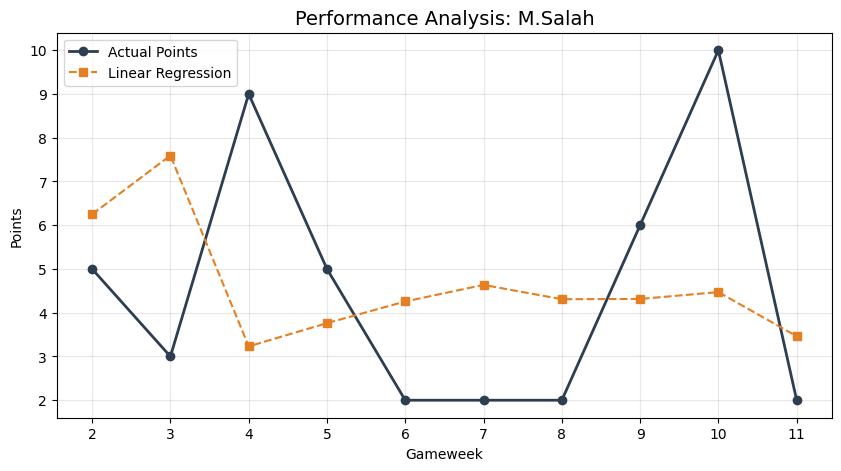

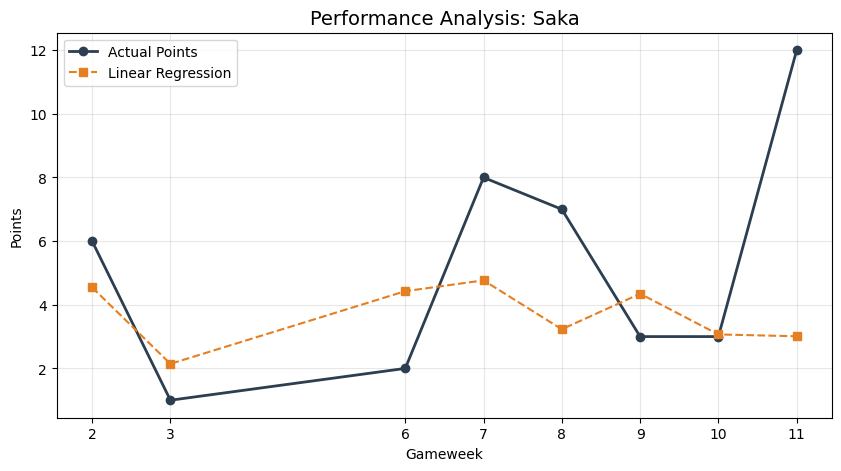

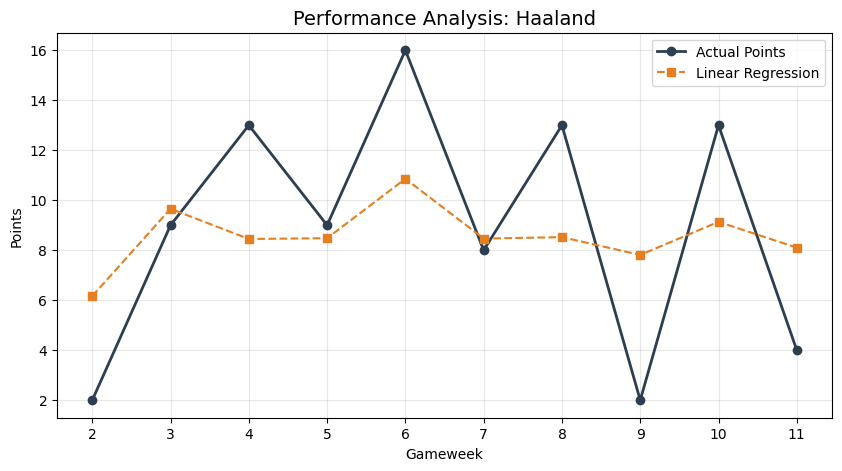

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df_preds = pd.read_csv("../output/models/linreg2/linear_regression_predictions.csv")


players_to_plot = ["M.Salah", "Saka", "Haaland"]

for player_name in players_to_plot:
    p_data = df_preds[df_preds["Web Name"] == player_name].sort_values("Prediction_GW")
    
    if p_data.empty:
        print(f" Player '{player_name}' not found in validation set.")
        continue
        
    # Δημιουργία γραφήματος
    plt.figure(figsize=(10, 5))
    
    # Actual Points (Μαύρο)
    plt.plot(p_data["Prediction_GW"], p_data["Total_Points_Actual"], 
             marker='o', label='Actual Points', color='#2C3E50', linewidth=2)
    
    # Linear Regression (Πορτοκαλί)
    plt.plot(p_data["Prediction_GW"], p_data["Total_Points_Predicted"], 
             marker='s', label='Linear Regression', linestyle='--', color='#E67E22')

    plt.title(f"Performance Analysis: {player_name}", fontsize=14)
    plt.xlabel("Gameweek")
    plt.ylabel("Points")
    plt.xticks(p_data["Prediction_GW"])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR_LASSO = Path("..") / "output" / "models" / "lasso"
OUT_DIR_LASSO.mkdir(parents=True, exist_ok=True)

print("Training Lasso Regression model...")

# 2. Training (alpha=0.1 as a starting point)
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

# 3. Predictions
y_train_pred_lasso = lasso_model.predict(X_train)
y_val_pred_lasso = lasso_model.predict(X_val)
y_all_pred_lasso = lasso_model.predict(X) # Predictions for the entire dataset

# 4. Metrics Calculation
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
mae_val_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
rmse_val_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))

print(f"Lasso Performance: MAE Validation = {mae_val_lasso:.4f}")

# 5. Update central performance file
update_model_performance(
    model_name="Lasso Regression (alpha=0.1)", 
    mae_train=mae_train_lasso, 
    mae_val=mae_val_lasso, 
    rmse_train=rmse_train_lasso, 
    rmse_val=rmse_val_lasso
)

# 6. Save Predictions
df_lasso_out = df_lr.copy()
df_lasso_out["Total_Points_Actual"] = df_lasso_out["Target_NextGW"]
df_lasso_out["Total_Points_Predicted"] = y_all_pred_lasso
df_lasso_out["Error(Actual-Predicted)"] = (
    df_lasso_out["Total_Points_Actual"] - df_lasso_out["Total_Points_Predicted"]
).abs()

keep_cols = [
    "Player UUID", "Player Name", "Web Name", 
    "Prediction_GW", "Total_Points_Actual", 
    "Total_Points_Predicted", "Error(Actual-Predicted)", "Split"
]

df_lasso_out[keep_cols].to_csv(
    OUT_DIR_LASSO / "lasso_predictions.csv", 
    index=False, 
    encoding="utf-8-sig"
)

# 7. Save Coefficients (coefficients.csv)
coeff_lasso = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
}).sort_values("Coefficient", ascending=False)

intercept_lasso = pd.DataFrame([{
    "Feature": "Intercept",
    "Coefficient": lasso_model.intercept_
}])

final_coeffs_lasso = pd.concat([intercept_lasso, coeff_lasso], ignore_index=True)
final_coeffs_lasso.to_csv(
    OUT_DIR_LASSO / "coefficients.csv", 
    index=False, 
    encoding="utf-8-sig"
)

print(f"Lasso outputs saved to: {OUT_DIR_LASSO}")

# Inspection: Which features were zeroed out?
zero_coeffs = final_coeffs_lasso[final_coeffs_lasso["Coefficient"] == 0]
if not zero_coeffs.empty:
    print("\nImportant: Lasso zeroed out the following features:")
    print(zero_coeffs["Feature"].tolist())
else:
    print("\nLasso kept all features (no coefficients are 0).")

Training Lasso Regression model...
Lasso Performance: MAE Validation = 3.1595
 model_performance.csv updated (Overwrite): Lasso Regression (alpha=0.1)
Lasso outputs saved to: ..\output\models\lasso

Important: Lasso zeroed out the following features:
['Avg_Goals Scored_L5', 'Avg_Assists_L5', 'Position_GK', 'Avg_Goals Conceded_L5', 'Avg_ICT Index_L5']


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR_LGB = Path("..") / "output" / "models" / "lightgbm"
OUT_DIR_LGB.mkdir(parents=True, exist_ok=True)

print("Training LightGBM Regressor...")

# 2. Training
# Parameters:
# n_estimators: Number of boosting rounds
# learning_rate: Step size shrinkage
# max_depth: Limits the depth of the tree
# verbosity: -1 to keep the output clean
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

# 3. Predictions
y_train_pred_lgb = lgb_model.predict(X_train)
y_val_pred_lgb = lgb_model.predict(X_val)
y_all_pred_lgb = lgb_model.predict(X)

# 4. Metrics Calculation
mae_train_lgb = mean_absolute_error(y_train, y_train_pred_lgb)
mae_val_lgb = mean_absolute_error(y_val, y_val_pred_lgb)
rmse_train_lgb = np.sqrt(mean_squared_error(y_train, y_train_pred_lgb))
rmse_val_lgb = np.sqrt(mean_squared_error(y_val, y_val_pred_lgb))

print(f"LightGBM Performance: MAE Validation = {mae_val_lgb:.4f}")

# 5. Update central performance file
update_model_performance(
    model_name="LightGBM", 
    mae_train=mae_train_lgb, 
    mae_val=mae_val_lgb, 
    rmse_train=rmse_train_lgb, 
    rmse_val=rmse_val_lgb
)

# 6. Save Predictions (lgb_predictions.csv)
df_lgb_out = df_lr.copy()
df_lgb_out["Total_Points_Actual"] = df_lgb_out["Target_NextGW"]
df_lgb_out["Total_Points_Predicted"] = y_all_pred_lgb
df_lgb_out["Error(Actual-Predicted)"] = (
    df_lgb_out["Total_Points_Actual"] - df_lgb_out["Total_Points_Predicted"]
).abs()

keep_cols = [
    "Player UUID", "Player Name", "Web Name", 
    "Prediction_GW", "Total_Points_Actual", 
    "Total_Points_Predicted", "Error(Actual-Predicted)", "Split"
]

df_lgb_out[keep_cols].to_csv(
    OUT_DIR_LGB / "lgb_predictions.csv", 
    index=False, 
    encoding="utf-8-sig"
)

# 7. Feature Importance
importance_lgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_lgb.to_csv(
    OUT_DIR_LGB / "feature_importance.csv", 
    index=False, 
    encoding="utf-8-sig"
)

print(f"LightGBM outputs saved to: {OUT_DIR_LGB}")
print("\nTop 5 Most Important Features in LightGBM:")
print(importance_lgb.head(5))

Training LightGBM Regressor...
LightGBM Performance: MAE Validation = 3.4139
 model_performance.csv updated (Overwrite): LightGBM
LightGBM outputs saved to: ..\output\models\lightgbm

Top 5 Most Important Features in LightGBM:
                 Feature  Importance
7      Avg_Creativity_L5         184
0    Avg_Total Points_L5         155
5       Avg_ICT Index_L5         144
1  Avg_Minutes Played_L5         138
4  Avg_Goals Conceded_L5         132


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define output directory
OUT_DIR_RF = Path("..") / "output" / "models" / "random_forest"
OUT_DIR_RF.mkdir(parents=True, exist_ok=True)

print("Training Random Forest Regressor...")

# 2. Training
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 3. Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_all_pred_rf = rf_model.predict(X)

# 4. Metrics
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
mae_val_rf = mean_absolute_error(y_val, y_val_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))

print(f"Random Forest Performance: MAE Validation = {mae_val_rf:.4f}")

# 5. Update performance file
update_model_performance(
    model_name="Random Forest", 
    mae_train=mae_train_rf, 
    mae_val=mae_val_rf, 
    rmse_train=rmse_train_rf, 
    rmse_val=rmse_val_rf
)

# 6. Save outputs
df_rf_out = df_lr.copy()
df_rf_out["Total_Points_Actual"] = df_rf_out["Target_NextGW"]
df_rf_out["Total_Points_Predicted"] = y_all_pred_rf
df_rf_out["Error(Actual-Predicted)"] = (df_rf_out["Total_Points_Actual"] - df_rf_out["Total_Points_Predicted"]).abs()

df_rf_out[keep_cols].to_csv(OUT_DIR_RF / "rf_predictions.csv", index=False, encoding="utf-8-sig")

# 7. Importance
importance_rf = pd.DataFrame({"Feature": X.columns, "Importance": rf_model.feature_importances_}).sort_values("Importance", ascending=False)
importance_rf.to_csv(OUT_DIR_RF / "feature_importance.csv", index=False, encoding="utf-8-sig")

print(f"Random Forest outputs saved to: {OUT_DIR_RF}")

Training Random Forest Regressor...
Random Forest Performance: MAE Validation = 3.2977
 model_performance.csv updated (Overwrite): Random Forest
Random Forest outputs saved to: ..\output\models\random_forest


In [64]:

import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Define output directory
OUT_DIR_GBM = Path("..") / "output" / "models" / "gbm"
OUT_DIR_GBM.mkdir(parents=True, exist_ok=True)

def objective(trial):
    # Defining the search space for hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }
    
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("Starting Optuna optimization for GBM...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # 30 trials is a good balance for speed/accuracy

print(f"Best trial: {study.best_trial.value:.4f}")
print("Best hyperparameters:", study.best_params)

# 2. Training the final model with best parameters
best_gbm = GradientBoostingRegressor(**study.best_params, random_state=42)
best_gbm.fit(X_train, y_train)

# 3. Predictions
y_train_pred_gbm = best_gbm.predict(X_train)
y_val_pred_gbm = best_gbm.predict(X_val)
y_all_pred_gbm = best_gbm.predict(X)

# 4. Metrics
mae_train_gbm = mean_absolute_error(y_train, y_train_pred_gbm)
mae_val_gbm = mean_absolute_error(y_val, y_val_pred_gbm)
rmse_train_gbm = np.sqrt(mean_squared_error(y_train, y_train_pred_gbm))
rmse_val_gbm = np.sqrt(mean_squared_error(y_val, y_val_pred_gbm))

print(f"Final GBM Performance: MAE Validation = {mae_val_gbm:.4f}")

# 5. Update performance file
update_model_performance(
    model_name="GBM (Optuna Optimized)", 
    mae_train=mae_train_gbm, 
    mae_val=mae_val_gbm, 
    rmse_train=rmse_train_gbm, 
    rmse_val=rmse_val_gbm
)

# 6. Save outputs
df_gbm_out = df_lr.copy()
df_gbm_out["Total_Points_Actual"] = df_gbm_out["Target_NextGW"]
df_gbm_out["Total_Points_Predicted"] = y_all_pred_gbm
df_gbm_out["Error(Actual-Predicted)"] = (df_gbm_out["Total_Points_Actual"] - df_gbm_out["Total_Points_Predicted"]).abs()

df_gbm_out[keep_cols].to_csv(OUT_DIR_GBM / "gbm_predictions.csv", index=False, encoding="utf-8-sig")

# 7. Importance
importance_gbm = pd.DataFrame({"Feature": X.columns, "Importance": best_gbm.feature_importances_}).sort_values("Importance", ascending=False)
importance_gbm.to_csv(OUT_DIR_GBM / "feature_importance.csv", index=False, encoding="utf-8-sig")

print(f"GBM outputs saved to: {OUT_DIR_GBM}")

[I 2026-01-21 20:11:35,736] A new study created in memory with name: no-name-3196f0ac-8a0b-4b32-b485-e6c98cba7cbe
[I 2026-01-21 20:11:35,888] Trial 0 finished with value: 3.479082778324323 and parameters: {'n_estimators': 187, 'learning_rate': 0.1414536643074342, 'max_depth': 5, 'min_samples_split': 5, 'subsample': 0.762083314373049}. Best is trial 0 with value: 3.479082778324323.


Starting Optuna optimization for GBM...


[I 2026-01-21 20:11:36,047] Trial 1 finished with value: 3.589511618349195 and parameters: {'n_estimators': 297, 'learning_rate': 0.017185200105197054, 'max_depth': 3, 'min_samples_split': 3, 'subsample': 0.8563305824787972}. Best is trial 0 with value: 3.479082778324323.
[I 2026-01-21 20:11:36,182] Trial 2 finished with value: 3.7976219181108415 and parameters: {'n_estimators': 171, 'learning_rate': 0.0623257792695155, 'max_depth': 7, 'min_samples_split': 6, 'subsample': 0.7389919119846642}. Best is trial 0 with value: 3.479082778324323.
[I 2026-01-21 20:11:36,287] Trial 3 finished with value: 3.3710716637488214 and parameters: {'n_estimators': 153, 'learning_rate': 0.010945448385976242, 'max_depth': 4, 'min_samples_split': 5, 'subsample': 0.9606750007775583}. Best is trial 3 with value: 3.3710716637488214.
[I 2026-01-21 20:11:36,433] Trial 4 finished with value: 3.8647592820766095 and parameters: {'n_estimators': 216, 'learning_rate': 0.0614682319613521, 'max_depth': 4, 'min_samples_

Best trial: 3.1608
Best hyperparameters: {'n_estimators': 55, 'learning_rate': 0.010872786507572497, 'max_depth': 3, 'min_samples_split': 2, 'subsample': 0.9932455983038311}
Final GBM Performance: MAE Validation = 3.1608
 model_performance.csv updated (Overwrite): GBM (Optuna Optimized)
GBM outputs saved to: ..\output\models\gbm


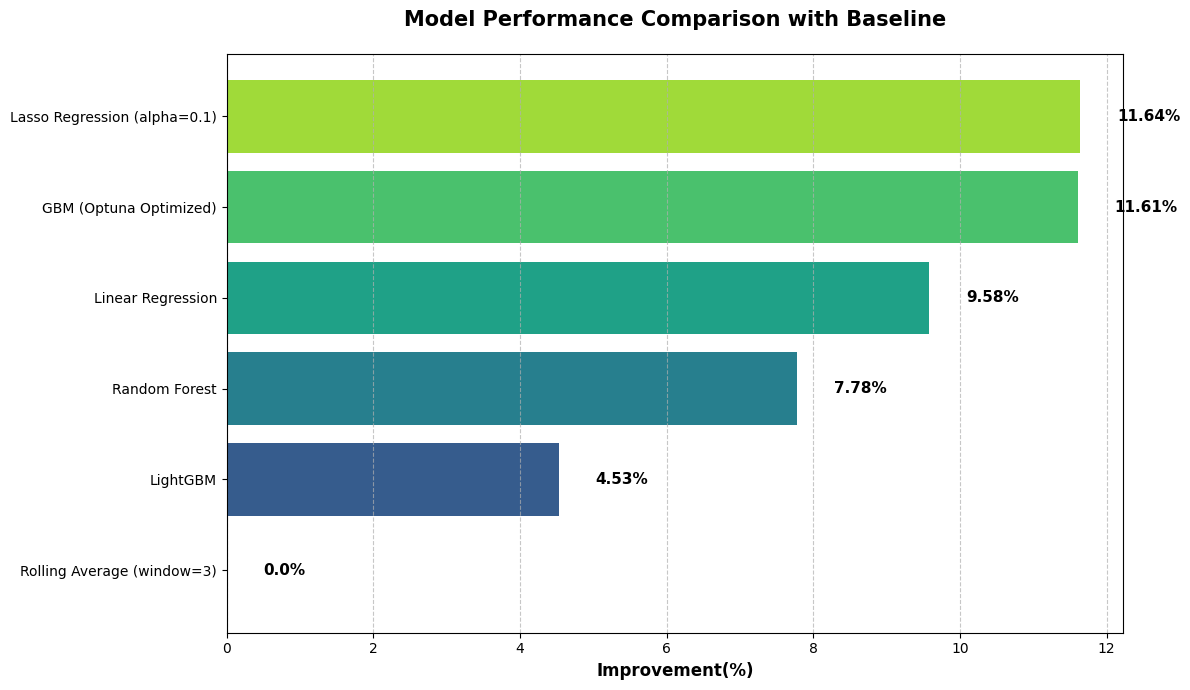

Final comparison chart saved to: ../output/models/model_comparison_improvement.png


In [69]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load the performance data
perf_path = Path("../output/models/models_performance.csv")
if perf_path.exists():
    df_perf = pd.read_csv(perf_path)
    
    # Sort by improvement for better visualization
    df_perf = df_perf.sort_values("Improvement_vs_Baseline (%)", ascending=True)

    # 2. Create the Bar Chart
    plt.figure(figsize=(12, 7))
    
    # Use a nice color palette
    colors = sns.color_palette("viridis", len(df_perf))
    
    bars = plt.barh(df_perf["Model"], df_perf["Improvement_vs_Baseline (%)"], color=colors)

    # Add labels and styling
    plt.xlabel("Improvement(%)", fontsize=12, fontweight='bold')
    plt.title("Model Performance Comparison with Baseline", fontsize=15, fontweight='bold', pad=20)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add the percentage values on the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{width}%', va='center', fontsize=11, fontweight='bold')

    # Highlight the winner
    plt.tight_layout()
    
    # 3. Save the final plot
    plt.savefig("../output/models/model_comparison_improvement.png", dpi=300)
    plt.show()
    
    print("Final comparison chart saved to: ../output/models/model_comparison_improvement.png")
else:
    print("Error: models_performance.csv not found. Please run your models first.")